---
**题名:** GPU 通信原语

**门类:** gpu-communication

**难易:** 初

**所需时辰:** 约二刻

---

# GPU 通传之基

欲明数据并行、张量并行诸策，先须知 **GPU 间何以通传**。此篇述集合通传之基本操作，凡并行之术皆由此出。

## 一、何须集合通传？

设四 GPU 协力训模型。某时须 **共享数据** —— 梯度、激活、参数。朴素之法：各 GPU 向余者各发一讯。四器则十二讯，六十四器则 **四千零三十二讯**。

**集合通传**者，以一次逻辑调用替万千点对点消息。通传库（NVIDIA GPU 之 NCCL）内部自行优化路由。

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from mp_tutorial.distributed import (
    simulate_broadcast, simulate_allreduce, simulate_allgather, simulate_reduce_scatter
)
from mp_tutorial.viz import draw_comm_pattern, draw_p2p_vs_collective, show_matrix, show_matrices_row
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

### 点对点与集合 —— 一览而知

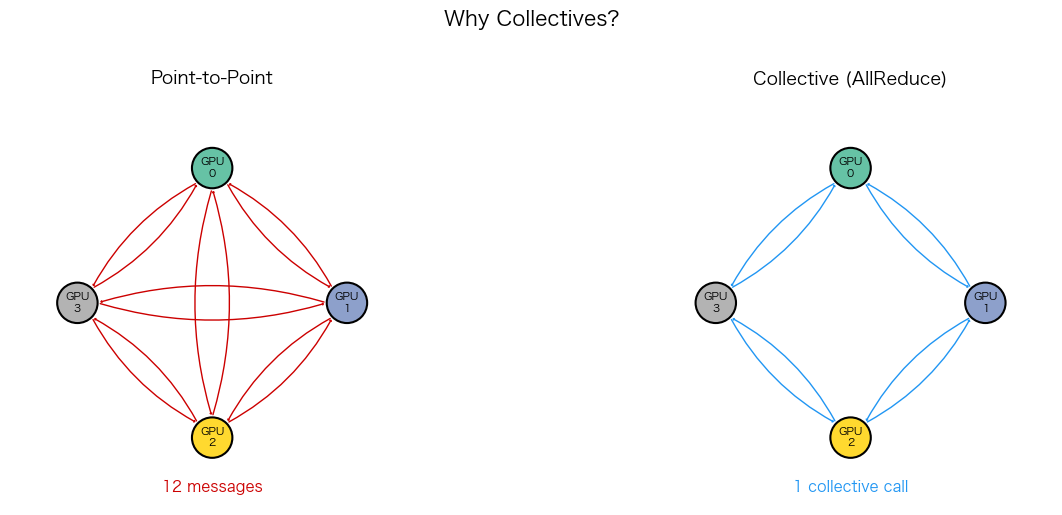

In [2]:
draw_p2p_vs_collective(num_gpus=4)
plt.show()

### 七种集合通传

依序而述 —— 先简后繁：

| # | 操作 | 所为 | 用于 |
|---|------|------|------|
| 一 | **Broadcast** | 由一器复制至众器 | 权重初始 |
| 二 | **Scatter** | 由一器分散至众器 | 数据分发 |
| 三 | **Gather** | 众器归集于一器 | 结果收集 |
| 四 | **AllGather** | 归集而众器皆得 | SP, FSDP |
| 五 | **Reduce** | 求和归于一器 | — |
| 六 | **ReduceScatter** | 求和而各得一块 | SP, FSDP |
| 七 | **AllReduce** | 求和而众器皆得 | DP 梯度同步 |

---
## 二、Broadcast（广播）

集合通传之最简者：一器将数据发于**众器**。众器终得同一副本。

**用途：** 训练之初，由 GPU 0 分发初始权重于众 GPU。

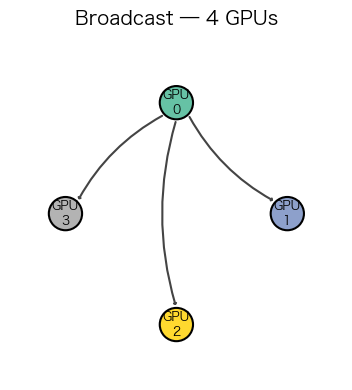

In [3]:
draw_comm_pattern("broadcast", num_gpus=4, figsize=(5, 4))
plt.show()

In [4]:
# GPU 0 有一张量；余器尚空
source = torch.tensor([1.0, 2.0, 3.0, 4.0])
print("广播前：")
print(f"  GPU 0: {source}")
print(f"  GPU 1-3:（空）")

result = simulate_broadcast(source, num_gpus=4)
print("\n广播后：")
for i, t in enumerate(result):
    print(f"  GPU {i}: {t}")

广播前：
  GPU 0: tensor([1., 2., 3., 4.])
  GPU 1-3:（空）

广播后：
  GPU 0: tensor([1., 2., 3., 4.])
  GPU 1: tensor([1., 2., 3., 4.])
  GPU 2: tensor([1., 2., 3., 4.])
  GPU 3: tensor([1., 2., 3., 4.])


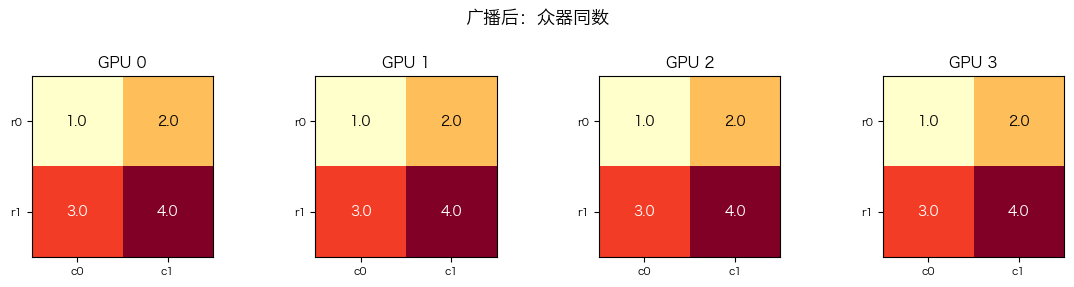

In [5]:
# 示：一源四同
source = torch.tensor([[1., 2.], [3., 4.]])
result = simulate_broadcast(source, num_gpus=4)
show_matrices_row(result, titles=[f"GPU {i}" for i in range(4)], suptitle="广播后：众器同数")
plt.show()

---
## 三、Scatter（散射）

根器将数据**拆分**为 N 块，第 *i* 块发于 GPU *i*。各器得**不同**之部分。

**用途：** 将训练数据之 batch 分发于各器，各处不同部分。

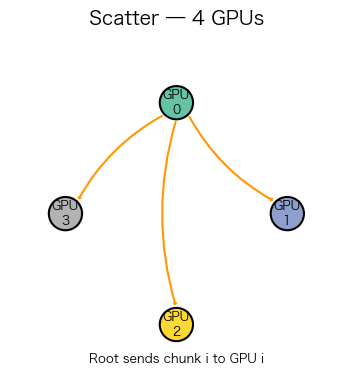

In [6]:
draw_comm_pattern("scatter", num_gpus=4, figsize=(5, 4))
plt.show()

In [7]:
# GPU 0 有一大张量待分发
data = torch.arange(12).reshape(4, 3).float()
print("散射前（GPU 0 所有）：")
print(data)

# 沿 dim 0 分为四块
chunks = list(data.chunk(4, dim=0))
print("\n散射后：")
for i, chunk in enumerate(chunks):
    print(f"  GPU {i}: {chunk.squeeze()}")

散射前（GPU 0 所有）：
tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])

散射后：
  GPU 0: tensor([0., 1., 2.])
  GPU 1: tensor([3., 4., 5.])
  GPU 2: tensor([6., 7., 8.])
  GPU 3: tensor([ 9., 10., 11.])


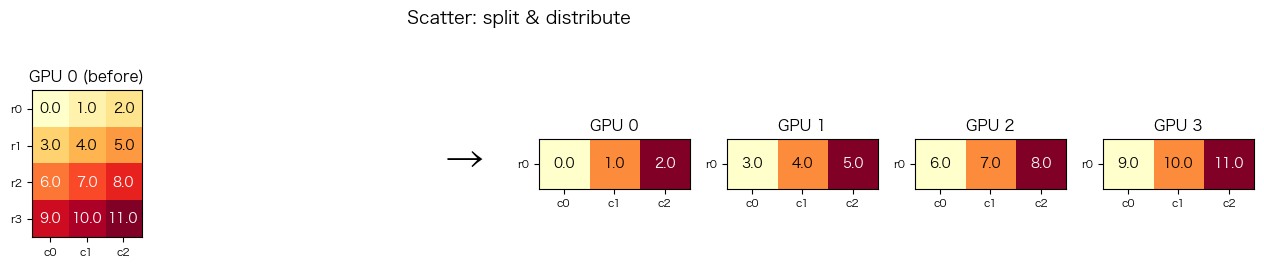

In [8]:
# Scatter 可视化：一个完整矩阵 → 四个不同的块
fig, axes = plt.subplots(1, 6, figsize=(15, 2.5), gridspec_kw={'width_ratios': [4, 0.5, 1, 1, 1, 1]})

data = torch.arange(12).reshape(4, 3).float()
show_matrix(data, ax=axes[0], title="GPU 0 (before)")

axes[1].text(0.5, 0.5, "→", fontsize=28, ha='center', va='center', fontweight='bold')
axes[1].axis('off')

chunks = list(data.chunk(4, dim=0))
for i, chunk in enumerate(chunks):
    show_matrix(chunk, ax=axes[i+2], title=f"GPU {i}")

fig.suptitle("Scatter: split & distribute", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 四、Gather（收集）

**Scatter 之逆**：各器将数据发于根器，根器拼接之。

**用途：** 将各器之部分结果收于一器，以记日志或存检查点。

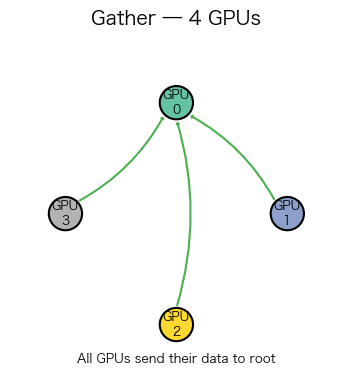

In [9]:
draw_comm_pattern("gather", num_gpus=4, figsize=(5, 4))
plt.show()

In [10]:
# 各器已算得部分结果
partials = [torch.tensor([i * 10 + j for j in range(3)]).float() for i in range(4)]
print("收集前：")
for i, p in enumerate(partials):
    print(f"  GPU {i}: {p}")

# 于根器拼接
gathered = torch.cat(partials, dim=0)
print(f"\n收集后（GPU 0）: {gathered}")

收集前：
  GPU 0: tensor([0., 1., 2.])
  GPU 1: tensor([10., 11., 12.])
  GPU 2: tensor([20., 21., 22.])
  GPU 3: tensor([30., 31., 32.])

收集后（GPU 0）: tensor([ 0.,  1.,  2., 10., 11., 12., 20., 21., 22., 30., 31., 32.])


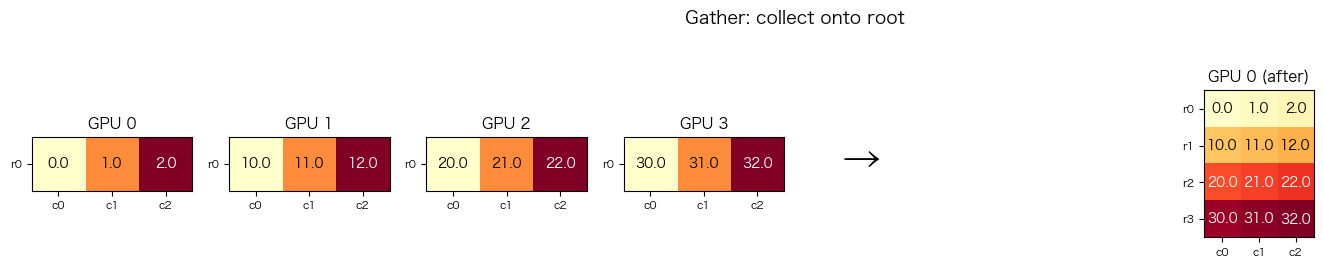

In [11]:
# Gather 可视化：各 GPU 的部分 → 根节点的完整数据
partials = [torch.tensor([[i * 10 + j for j in range(3)]]).float() for i in range(4)]
gathered = torch.cat(partials, dim=0)

fig, axes = plt.subplots(1, 6, figsize=(16, 2.5), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.5, 4]})
for i in range(4):
    show_matrix(partials[i], ax=axes[i], title=f"GPU {i}")

axes[4].text(0.5, 0.5, "→", fontsize=28, ha='center', va='center', fontweight='bold')
axes[4].axis('off')

show_matrix(gathered, ax=axes[5], title="GPU 0 (after)")
fig.suptitle("Gather: collect onto root", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 五、AllGather（全收集）

如 Gather，然**众器皆得**完整拼接结果，非仅根器。

$$\text{AllGather} = \text{Gather} + \text{Broadcast}$$

**用途：** 序列并行中，各器持序列之一块；入 TP 层前，AllGather 于众器重建完整序列。

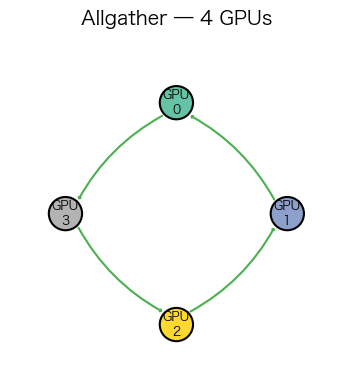

In [12]:
draw_comm_pattern("allgather", num_gpus=4, figsize=(5, 4))
plt.show()

In [13]:
# 各器持序列之一块
chunks = [torch.tensor([[i, i+0.5]]) for i in range(4)]
print("全收集前（各器有其块）：")
for i, c in enumerate(chunks):
    print(f"  GPU {i}: {c.squeeze()}")

result = simulate_allgather(chunks)
print("\n全收集后（众器皆有完整序列）：")
for i, r in enumerate(result):
    print(f"  GPU {i}: {r}")

全收集前（各器有其块）：
  GPU 0: tensor([0.0000, 0.5000])
  GPU 1: tensor([1.0000, 1.5000])
  GPU 2: tensor([2.0000, 2.5000])
  GPU 3: tensor([3.0000, 3.5000])

全收集后（众器皆有完整序列）：
  GPU 0: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])
  GPU 1: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])
  GPU 2: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])
  GPU 3: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])


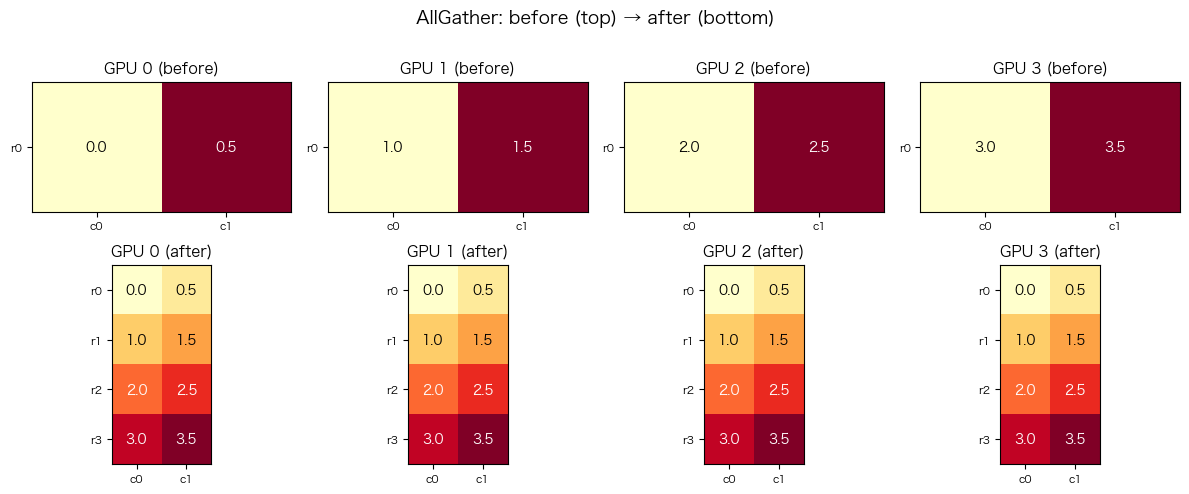

In [14]:
# AllGather 可视化：各 GPU 有一块 → 所有 GPU 有完整数据
chunks = [torch.tensor([[i, i + 0.5]]) for i in range(4)]
full = torch.cat(chunks, dim=0)

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.suptitle("AllGather: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(chunks[i], ax=axes[0, i], title=f"GPU {i} (before)")
for i in range(4):
    show_matrix(full, ax=axes[1, i], title=f"GPU {i} (after)")

plt.tight_layout()
plt.show()

---
## 六、Reduce（归约）

众器各出一张量，**求和**而结果**仅**落于根器。

$$\text{Reduce}(\text{GPU}_0, \text{GPU}_1, \ldots) = \sum_i \text{GPU}_i \quad \text{（结果仅在根器）}$$

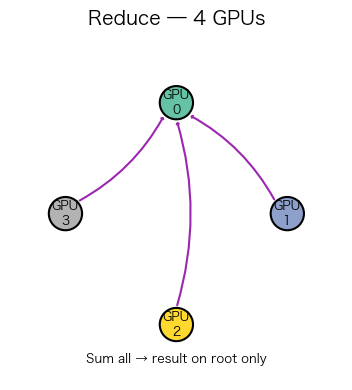

In [15]:
draw_comm_pattern("reduce", num_gpus=4, figsize=(5, 4))
plt.show()

In [16]:
# 各器已算本地梯度
grads = [torch.tensor([1.0, 2.0, 3.0]) * (i + 1) for i in range(4)]
print("归约前（各器之梯度）：")
for i, g in enumerate(grads):
    print(f"  GPU {i}: {g}")

# 求和于 GPU 0
reduced = torch.stack(grads).sum(dim=0)
print(f"\n归约后（仅 GPU 0）: {reduced}")
print(f"  GPU 1-3:（无结果）")

归约前（各器之梯度）：
  GPU 0: tensor([1., 2., 3.])
  GPU 1: tensor([2., 4., 6.])
  GPU 2: tensor([3., 6., 9.])
  GPU 3: tensor([ 4.,  8., 12.])

归约后（仅 GPU 0）: tensor([10., 20., 30.])
  GPU 1-3:（无结果）


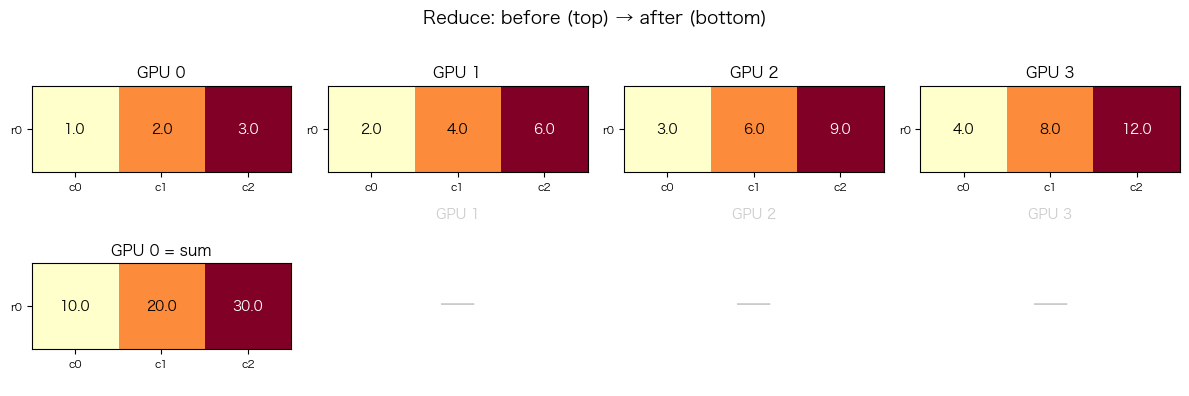

In [17]:
# Reduce 可视化：各 GPU 有数据 → 仅根节点有总和
grads = [torch.tensor([[1.0, 2.0, 3.0]]) * (i + 1) for i in range(4)]
reduced = torch.stack([g.squeeze() for g in grads]).sum(dim=0, keepdim=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 4))
fig.suptitle("Reduce: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(grads[i], ax=axes[0, i], title=f"GPU {i}")
show_matrix(reduced, ax=axes[1, 0], title="GPU 0 = sum")
for i in range(1, 4):
    axes[1, i].text(0.5, 0.5, "—", fontsize=24, ha='center', va='center', color='#ccc')
    axes[1, i].set_title(f"GPU {i}", fontsize=10, color='#ccc')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
## 七、ReduceScatter（归约散射）

**一步行 Reduce + Scatter**：众张量求和，而后拆分，第 *i* 块归 GPU *i*。各器得求和结果之**不同分块**。

$$\text{ReduceScatter} = \text{Reduce} + \text{Scatter}$$

**用途：** SP 中，TP 行并行层后，ReduceScatter 对部分激活求和并将序列块分回各器。

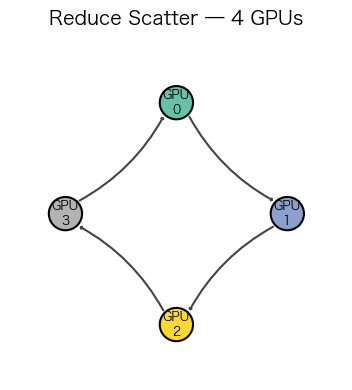

In [18]:
draw_comm_pattern("reduce_scatter", num_gpus=4, figsize=(5, 4))
plt.show()

In [19]:
# 各器有部分激活张量（各四行）
partials = [torch.ones(4, 2) * (i + 1) for i in range(4)]
print("归约散射前：")
for i, p in enumerate(partials):
    print(f"  GPU {i}: 总和={p.sum().item():.0f}  形={tuple(p.shape)}")

result = simulate_reduce_scatter(partials)
print("\n归约散射后（各器得总和之一块）：")
for i, r in enumerate(result):
    print(f"  GPU {i}: {r.squeeze()}  形={tuple(r.shape)}")

归约散射前：
  GPU 0: 总和=8  形=(4, 2)
  GPU 1: 总和=16  形=(4, 2)
  GPU 2: 总和=24  形=(4, 2)
  GPU 3: 总和=32  形=(4, 2)

归约散射后（各器得总和之一块）：
  GPU 0: tensor([10., 10.])  形=(1, 2)
  GPU 1: tensor([10., 10.])  形=(1, 2)
  GPU 2: tensor([10., 10.])  形=(1, 2)
  GPU 3: tensor([10., 10.])  形=(1, 2)


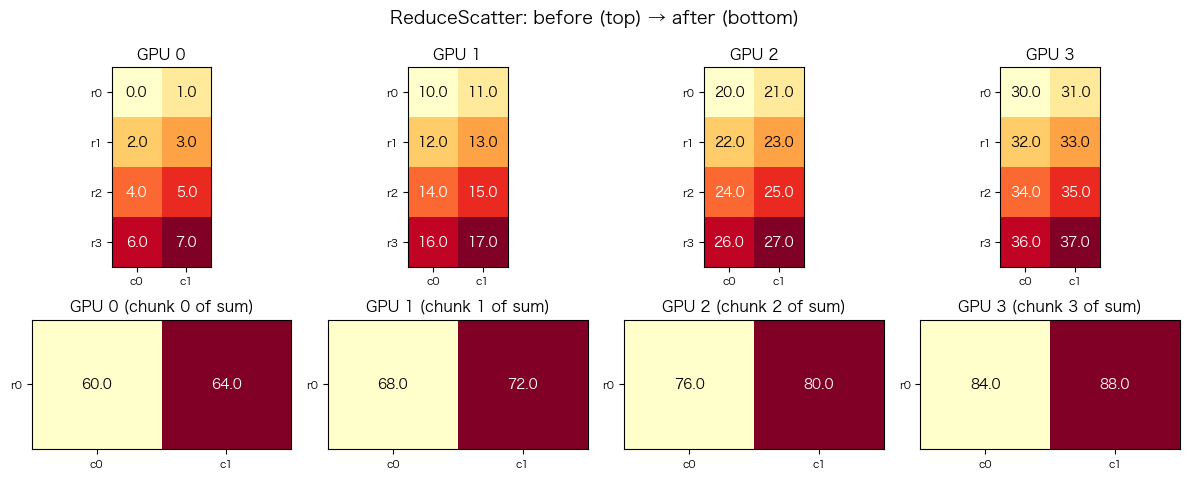

In [20]:
# ReduceScatter 可视化：各 GPU 有完整数据 → 各得总和的一块
partials = [torch.arange(8).reshape(4, 2).float() + (i * 10) for i in range(4)]
total = torch.stack(partials).sum(dim=0)
rs_chunks = list(total.chunk(4, dim=0))

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.suptitle("ReduceScatter: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(partials[i], ax=axes[0, i], title=f"GPU {i}")
for i in range(4):
    show_matrix(rs_chunks[i], ax=axes[1, i], title=f"GPU {i} (chunk {i} of sum)")

plt.tight_layout()
plt.show()

---
## 八、AllReduce（全归约）

分布式训练中至要之集合操作。众张量求和，**众器皆得完整结果**。

$$\text{AllReduce} = \text{ReduceScatter} + \text{AllGather}$$

**用途：** 数据并行中，各器于己之 batch 算梯度，而后 AllReduce 求均，使众器梯度同一以行优化器更新。

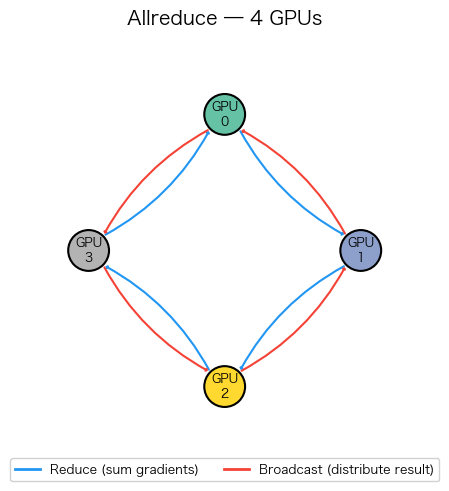

In [21]:
draw_comm_pattern("allreduce", num_gpus=4, figsize=(6, 5))
plt.show()

In [22]:
# 各器有本地梯度
torch.manual_seed(42)
local_grads = [torch.randn(2, 3).round() for _ in range(4)]
print("全归约前（各器本地梯度）：")
for i, g in enumerate(local_grads):
    print(f"  GPU {i}:")
    print(f"    {g[0].tolist()}")
    print(f"    {g[1].tolist()}")

result = simulate_allreduce(local_grads)
print("\n全归约后（众器皆有总和）：")
print(f"  众器: {result[0]}")
assert all(torch.equal(result[0], r) for r in result)
print("  ✓ 众器张量同一")

全归约前（各器本地梯度）：
  GPU 0:
    [0.0, 0.0, 0.0]
    [0.0, -1.0, -0.0]
  GPU 1:
    [2.0, -1.0, 0.0]
    [0.0, 1.0, 1.0]
  GPU 2:
    [1.0, -2.0, -1.0]
    [1.0, 1.0, 1.0]
  GPU 3:
    [-1.0, -1.0, 1.0]
    [1.0, -0.0, 1.0]

全归约后（众器皆有总和）：
  众器: tensor([[ 2., -4.,  0.],
        [ 2.,  1.,  3.]])
  ✓ 众器张量同一


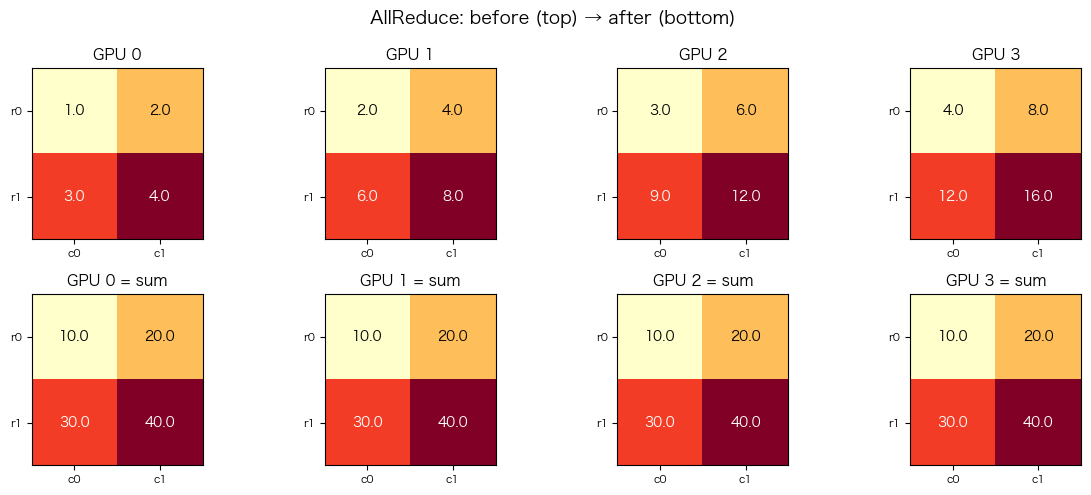

In [23]:
# AllReduce 可视化：各 GPU 有本地梯度 → 所有 GPU 有总和
torch.manual_seed(0)
local = [torch.tensor([[1., 2.], [3., 4.]]) * (i + 1) for i in range(4)]
summed = torch.stack(local).sum(dim=0)

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.suptitle("AllReduce: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(local[i], ax=axes[0, i], title=f"GPU {i}")
for i in range(4):
    show_matrix(summed, ax=axes[1, i], title=f"GPU {i} = sum")

plt.tight_layout()
plt.show()

### AllReduce = ReduceScatter + AllGather（环形算法）

实际中 AllReduce **非**单一操作 —— 乃由二基础原语组合而成：

1. **ReduceScatter**：众张量逐元素求和，而后第 *i* 块分与 GPU *i*
2. **AllGather**：各器共享所持之块，众器重构完整结果

此即 **Ring AllReduce** 算法：数据于 GPU 环上分二阶段流转。每器仅与左右邻通传，**众链路同时活跃** —— 几近最优之带宽利用。

```
阶段一：ReduceScatter（N-1 步）                   阶段二：AllGather（N-1 步）
┌──────────────────────────────┐                  ┌──────────────────────────────┐
│  GPU 0 ──chunk──▶ GPU 1     │                  │  GPU 0 ──chunk──▶ GPU 1     │
│  GPU 1 ──chunk──▶ GPU 2     │  累加            │  GPU 1 ──chunk──▶ GPU 2     │  复制最终
│  GPU 2 ──chunk──▶ GPU 3     │  部分和          │  GPU 2 ──chunk──▶ GPU 3     │  分块
│  GPU 3 ──chunk──▶ GPU 0     │                  │  GPU 3 ──chunk──▶ GPU 0     │
└──────────────────────────────┘                  └──────────────────────────────┘
之后：各器拥有总和之 1/N                          之后：各器拥有完整总和
```

**何以要紧**：N 器各持大小为 M 之张量，Ring AllReduce 每器传 `2M(N-1)/N` 字节。N 增而趋 `2M` —— 带宽之耗本质上**与器数无关**。

In [24]:
# 示 AllReduce = ReduceScatter + AllGather
grads = [torch.tensor([1., 2., 3., 4.]) * (i + 1) for i in range(4)]
print("入梯度：", [g.tolist() for g in grads])

# 第一步：ReduceScatter
rs_result = simulate_reduce_scatter(grads)
print("\n步一 — ReduceScatter（各器有总和之一块）：")
for i, r in enumerate(rs_result):
    print(f"  GPU {i}: {r.tolist()}")

# 第二步：AllGather
ag_result = simulate_allgather(rs_result)
print("\n步二 — AllGather（于众器重建完整结果）：")
for i, r in enumerate(ag_result):
    print(f"  GPU {i}: {r.tolist()}")

direct = simulate_allreduce(grads)
assert torch.equal(ag_result[0], direct[0])
print("\n✓ ReduceScatter + AllGather == AllReduce")

入梯度： [[1.0, 2.0, 3.0, 4.0], [2.0, 4.0, 6.0, 8.0], [3.0, 6.0, 9.0, 12.0], [4.0, 8.0, 12.0, 16.0]]

步一 — ReduceScatter（各器有总和之一块）：
  GPU 0: [10.0]
  GPU 1: [20.0]
  GPU 2: [30.0]
  GPU 3: [40.0]

步二 — AllGather（于众器重建完整结果）：
  GPU 0: [10.0, 20.0, 30.0, 40.0]
  GPU 1: [10.0, 20.0, 30.0, 40.0]
  GPU 2: [10.0, 20.0, 30.0, 40.0]
  GPU 3: [10.0, 20.0, 30.0, 40.0]

✓ ReduceScatter + AllGather == AllReduce


对应之 `torch.distributed` 调用：

```python
import torch.distributed as dist

# 直行 AllReduce —— NCCL 自择最佳算法（环形、树形等）
dist.all_reduce(tensor, op=dist.ReduceOp.SUM)

# 亦可显式分二步：
dist.reduce_scatter(output, input_list)   # 步一：各器得总和之一块
dist.all_gather(output_list, input)       # 步二：重构完整结果

# 基于张量之变体（Megatron-LM 中更常用）：
dist.reduce_scatter_tensor(output, input)  # 入为扁平张量，自行分块
dist.all_gather_into_tensor(output, input) # 收集至预分配之输出
```

---
## 九、点对点 (Send / Recv)

非集合操作 —— 二特定 GPU 间之**直传**。点对点通传有二式：

| API | 行为 | 适用 |
|-----|------|------|
| `dist.send()` / `dist.recv()` | **阻塞** —— 待传毕方返 | 简单顺序之流水线 |
| `dist.isend()` / `dist.irecv()` | **非阻塞** —— 即返 `Work` 柄 | 通传与算重叠；避死锁 |

**用途：** 流水线并行（PP）将激活从第 *i* 阶段发至第 *i+1* 阶段。Ring Attention（CP）于环上轮换 KV 块。

### 死锁之患

阻塞之 send/recv 于二器同时互发时致死锁：

```
❌ 死锁：双方皆阻于 send，无一至 recv
GPU 0: dist.send(tensor, dst=1)    # 阻塞，待 GPU 1 recv
GPU 1: dist.send(tensor, dst=0)    # 阻塞，待 GPU 0 recv
```

### 解方：用异步 (`isend` / `irecv`)

非阻塞调用即返 `Work` 柄。先发通传，行他算（或启对应之 recv），末于需结果时调 `.wait()`：

```python
# ✓ 安全：非阻塞不待
req0 = dist.isend(send_buf, dst=1)   # 即返
req1 = dist.irecv(recv_buf, src=1)   # 亦即返
req0.wait()                           # 待发送毕
req1.wait()                           # 待接收毕
```

此模式于**流水线并行**中至关重要 —— 各阶段须交换激活（前向）与梯度（反向）而不可互阻。

In [25]:
# 模拟 P2P：环形轮转（各器发至右邻）
# 此即 Ring Attention（上下文并行）所用之模式

num_gpus = 4
kv_blocks = [torch.tensor([i * 10 + 1, i * 10 + 2]).float() for i in range(num_gpus)]
print("环形 P2P 轮转（各器发至下一）：\n")
print("轮转前：")
for i, kv in enumerate(kv_blocks):
    print(f"  GPU {i}: {kv.tolist()}")

# 一步轮转：GPU i 发至 GPU (i+1) % N
rotated = [kv_blocks[(i - 1) % num_gpus] for i in range(num_gpus)]
print("\n一步轮转后：")
for i, kv in enumerate(rotated):
    src = (i - 1) % num_gpus
    print(f"  GPU {i}: {kv.tolist()}  （自 GPU {src} 受）")

环形 P2P 轮转（各器发至下一）：

轮转前：
  GPU 0: [1.0, 2.0]
  GPU 1: [11.0, 12.0]
  GPU 2: [21.0, 22.0]
  GPU 3: [31.0, 32.0]

一步轮转后：
  GPU 0: [31.0, 32.0]  （自 GPU 3 受）
  GPU 1: [1.0, 2.0]  （自 GPU 0 受）
  GPU 2: [11.0, 12.0]  （自 GPU 1 受）
  GPU 3: [21.0, 22.0]  （自 GPU 2 受）


---
## 十、`torch.distributed` API 概览

除上述通传原语外，`torch.distributed` 尚提供分布式训练所需之基础设施：

### 初始化与环境

```python
import torch.distributed as dist

# 初始化进程组 —— 必于一切通传之前调用
dist.init_process_group(
    backend="nccl",     # GPU 用 "nccl"，CPU 用 "gloo"
    init_method="env://",  # 或 "tcp://host:port"
    world_size=4,
    rank=0,
)

# 查己之身份
rank = dist.get_rank()                  # 此进程之索引 (0..world_size-1)
world_size = dist.get_world_size()      # 进程总数
local_rank = int(os.environ["LOCAL_RANK"])  # 本节点之 GPU 索引
```

### 进程组

**进程组**者，参与通传之 GPU 子集也。不同并行策略用不同之组：

```python
# 默认组：众 GPU
dist.all_reduce(tensor)   # 用默认（世界）组

# 创自定义组：如 GPU [0,1] 和 [2,3] 用于节点内 TP
tp_group = dist.new_group(ranks=[0, 1])
dist.all_reduce(tensor, group=tp_group)   # 仅 GPU 0 与 1 参与

# 于 Megatron-LM 中，可见 TP、DP、PP 用独立之组：
# tp_group = [0,1,2,3]  （节点内张量并行）
# dp_group = [0,4,8,12] （跨节点数据并行）
# pp_group = [0,16]     （流水线阶段）
```

### 同步与工具

```python
dist.barrier()              # 阻塞至众进程皆达此处
dist.barrier(group=tp_group)  # 仅于子组内同步

dist.is_initialized()      # 检进程组是否已立
dist.destroy_process_group()  # 终时清理
```

### 启动分布式脚本

```bash
# torchrun 自处 rank/world_size/LOCAL_RANK 环境变量
torchrun --nproc_per_node=4 train.py          # 单节点，四 GPU
torchrun --nnodes=2 --nproc_per_node=4 \
         --master_addr=node0 --master_port=29500 train.py  # 多节点
```

### 完整 API 速览

| 类别 | API |
|------|-----|
| **集合通传** | `all_reduce`, `all_gather`, `reduce_scatter`, `broadcast`, `reduce`, `scatter`, `gather` |
| **张量变体** | `all_gather_into_tensor`, `reduce_scatter_tensor`（免列表分配） |
| **点对点** | `send`, `recv`, `isend`, `irecv` |
| **批量 P2P** | `batch_isend_irecv` —— 一发多 P2P 操作 |
| **同步** | `barrier`, `monitored_barrier`（带超时） |
| **进程组** | `new_group`, `get_rank(group)`, `get_world_size(group)` |
| **启动** | `torchrun` CLI, `mp.spawn()`, `elastic_launch` |

### 点对点实战：流水线并行

流水线各阶段如何以异步 P2P 交换激活：

```python
# [GPU-REQUIRED] — 流水线第 i 阶段发激活至第 i+1 阶段
import torch.distributed as dist

rank = dist.get_rank()

if rank == 0:
    # 阶段 0：算毕发激活至阶段 1
    output = model_stage_0(input_batch)
    dist.send(output, dst=1)

elif rank == 1:
    # 阶段 1：自阶段 0 受，算毕发至阶段 2
    recv_buf = torch.empty_like(expected_shape)
    dist.recv(recv_buf, src=0)
    output = model_stage_1(recv_buf)
    dist.send(output, dst=2)

# 以 isend/irecv 行双向交换（避死锁）：
send_req = dist.isend(my_activations, dst=next_rank)
recv_req = dist.irecv(recv_buffer, src=prev_rank)
# ... 与本地算重叠 ...
send_req.wait()
recv_req.wait()
```

**另一安全之阻塞 send/recv 双向模式**：依 rank 奇偶交替 send/recv 之序。偶 rank 先发，奇 rank 先收 —— 无一对致死锁：

```python
if rank % 2 == 0:
    dist.send(tensor, dst=rank + 1)
    dist.recv(tensor, src=rank + 1)
else:
    dist.recv(tensor, src=rank - 1)
    dist.send(tensor, dst=rank - 1)
```

---
## 十一、带宽与延迟

二因素定通传之耗：

| 因素 | 义 | 譬喻 |
|------|-----|------|
| **延迟** | 每讯之固定开销（μs） | 执笔之时 |
| **带宽** | 数据传率（GB/s） | 书写之速 |

$$\text{耗时} = \text{延迟} + \frac{\text{消息大小}}{\text{带宽}}$$

**要旨：** 大消息（梯度、激活）中，带宽为主。集合通传之设计，旨在**使众器带宽利用率最大化**。

| 互连 | 带宽 | 典型用途 |
|------|------|----------|
| NVLink（节点内） | 600-900 GB/s | TP, SP |
| PCIe 5.0 | 64 GB/s | 节点内后备 |
| InfiniBand / RoCE（节点间） | 50-400 GB/s | DP, PP |

故 **TP 限于一节点**（须 NVLink 之速），而 **DP、PP 可跨节点**（每步通传量少）。

---
## 总括

| 操作 | 入 → 出 | 众器皆得？ | 要用 |
|------|---------|-----------|------|
| **Broadcast** | 一 → 众（复制） | ✓ | 权重初始 |
| **Scatter** | 一 → 众（拆分） | 各得一块 | 数据分发 |
| **Gather** | 众 → 一（拼接） | 仅根器 | 结果收集 |
| **AllGather** | 众 → 众（拼接） | ✓ | SP, FSDP |
| **Reduce** | 众 → 一（求和） | 仅根器 | — |
| **ReduceScatter** | 众 → 众（和+分） | 各得一块 | SP, FSDP |
| **AllReduce** | 众 → 众（求和） | ✓ | DP 梯度同步 |

### 组合之则

```
AllGather    = Gather    + Broadcast
AllReduce    = Reduce    + Broadcast
AllReduce    = ReduceScatter + AllGather   ← Ring 算法
```

### 延伸

- [NCCL 文档](https://docs.nvidia.com/deeplearning/nccl/user-guide/docs/overview.html) — NVIDIA 集合通传库
- [Megatron-LM 论文 (2020)](https://arxiv.org/abs/1909.08053) — 集合通传何以支撑大规模模型并行
- 次篇：**[一、数据并行](01-data-parallelism.ipynb)** — 观 AllReduce 之实践